# Лабораторная работа №4

In [35]:
import pandas as pd
import numpy as np
import random
import math
import matplotlib.pyplot as plt
import seaborn as sns

## Выбор датасетов: четный номер -> вино

In [36]:
np.random.seed(42)
random.seed(42)

data = pd.read_csv("data/WineDataset.csv")
data.describe()

,Alcohol,Malic Acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline,Wine
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,1.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,1.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,1.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,2.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,3.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,3.000000


## Проведите предварительную обработку данных, включая обработку отсутствующих значений, кодирование категориальных признаков и масштабирование.

In [37]:
if not data.isna().any().any():
    print("В данных нет пустых значений")
else:
    data.dropna(inplace=True)
    print("Пустые значения удалены")

В данных нет пустых значений


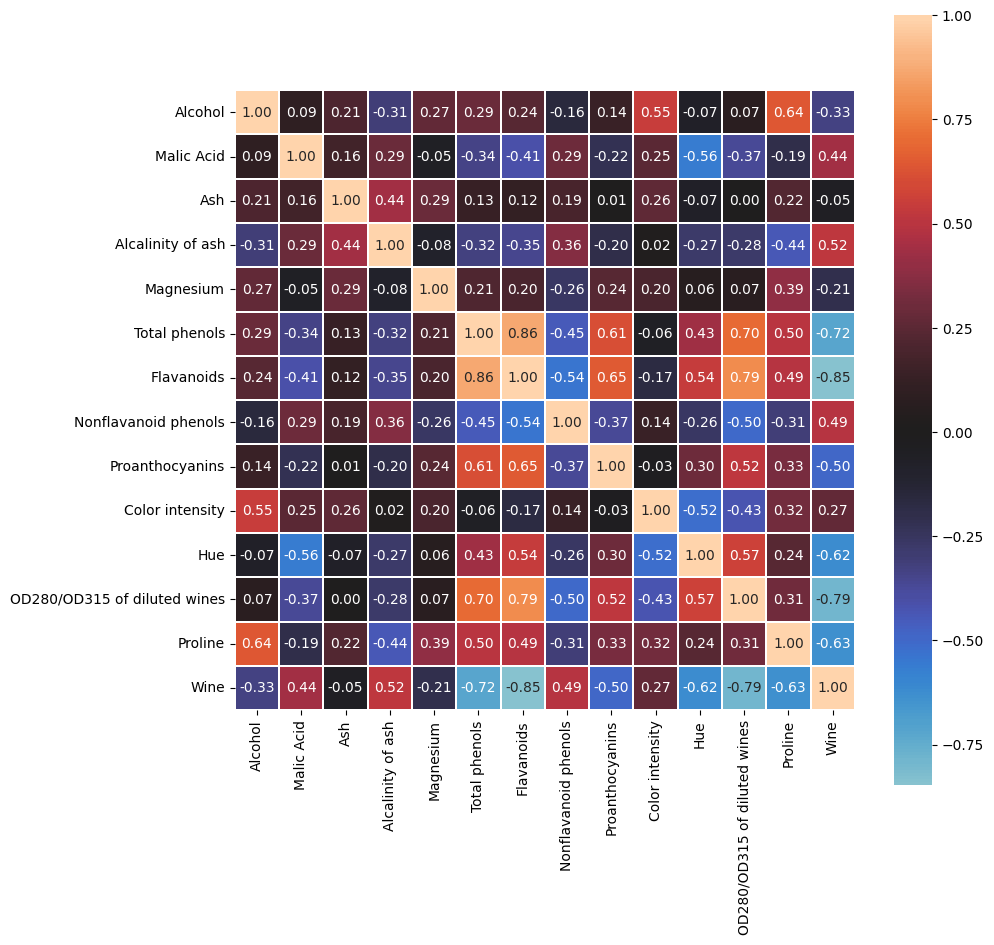

In [38]:
plt.figure(figsize=(10, 10))
sns.heatmap(data.corr(), annot=True, fmt=".2f", center=0,
            square=True, linewidths=0.1)
plt.show()

In [39]:
target_col = 'Wine'
X = data.drop(target_col, axis=1)
y = data[target_col]

X_scaled = (X - X.min()) / (X.max() - X.min())
data_scaled = pd.concat([X_scaled, y], axis=1)

## Получите и визуализируйте (графически) статистику по датасету (включая количество, среднее значение, стандартное отклонение, минимум, максимум и различные квантили), постройте 3d-визуализацию признаков.

In [40]:
print("Статистика по датасету:")
print(data.describe())

Статистика по датасету:
          Alcohol  Malic Acid         Ash  Alcalinity of ash   Magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       Total phenols  Flavanoids  Nonflavanoid phenols  Proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.124453         0.5

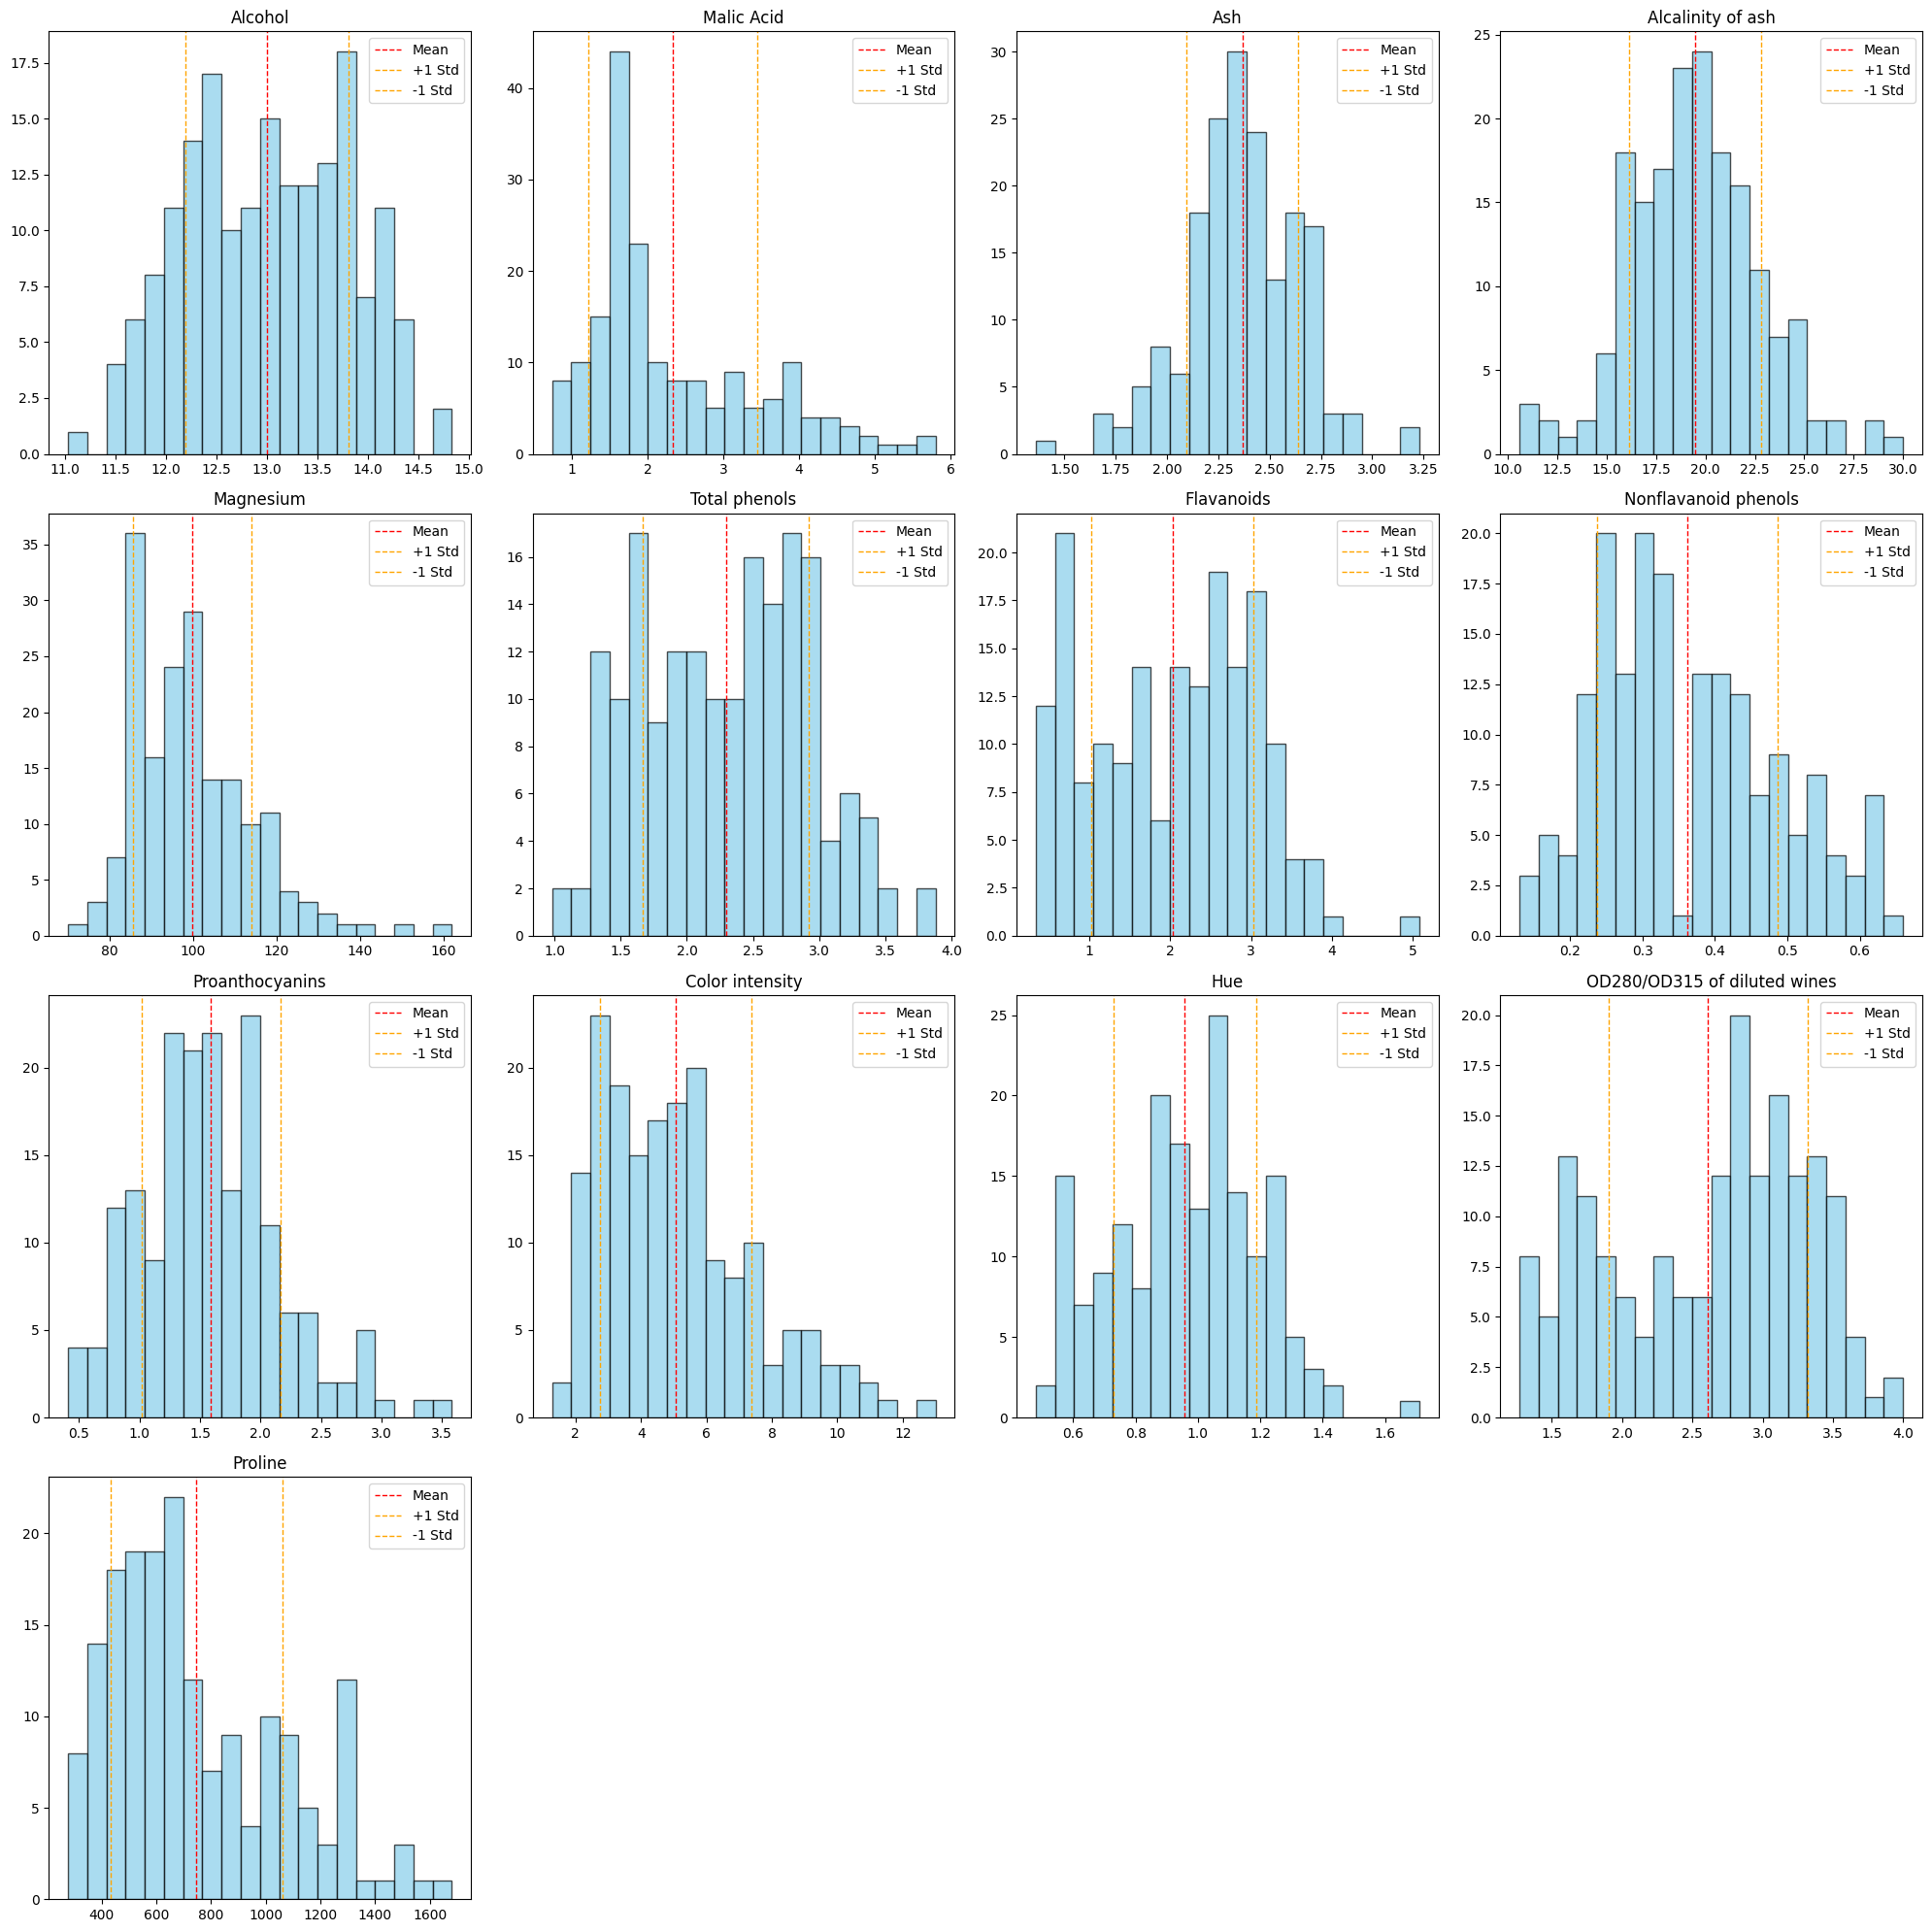

In [41]:
columns = X.columns
num_cols = 4
num_rows = (len(columns) + num_cols - 1) // num_cols

plt.figure(figsize=(20, 5 * num_rows))
for i, col in enumerate(columns):
    plt.subplot(num_rows, num_cols, i + 1)
    plt.hist(data[col], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title(col)
    
    mean_val = data[col].mean()
    std_val = data[col].std()
    plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=1, label='Mean')
    plt.axvline(mean_val + std_val, color='orange', linestyle='dashed', linewidth=1, label='+1 Std')
    plt.axvline(mean_val - std_val, color='orange', linestyle='dashed', linewidth=1, label='-1 Std')
    plt.legend()

plt.tight_layout()
plt.show()

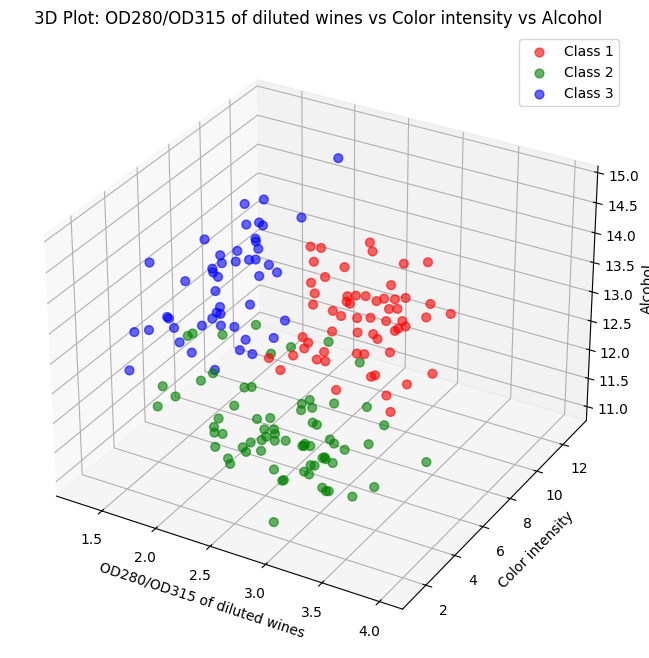

In [42]:
random_cols = np.random.choice(X.columns, 3, replace=False)
f1, f2, f3 = random_cols

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = {1: 'red', 2: 'green', 3: 'blue'}

for label in sorted(y.unique()):
    indices = y == label
    ax.scatter(
        data.loc[indices, f1], 
        data.loc[indices, f2], 
        data.loc[indices, f3], 
        c=colors[label], 
        label=f'Class {label}',
        s=40,
        alpha=0.6
    )

ax.set_xlabel(f1)
ax.set_ylabel(f2)
ax.set_zlabel(f3)
plt.title(f"3D Plot: {f1} vs {f2} vs {f3}")
plt.legend()
plt.show()

## Реализуйте метод k-ближайших соседей без использования сторонних библиотек, кроме NumPy и Pandas.

In [43]:
def manual_train_test_split(X, y, test_size=0.2):
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    
    split_idx = int(len(X) * (1 - test_size))
    train_idx, test_idx = indices[:split_idx], indices[split_idx:]
    
    return X.iloc[train_idx], X.iloc[test_idx], y.iloc[train_idx], y.iloc[test_idx]

def euclidean_dist(x_train, x_test_point):
    return np.sqrt(np.sum((x_train - x_test_point)**2, axis=1))

def predict_knn(X_train, y_train, X_test, k):
    predictions = []
    X_train_val = X_train.values
    y_train_val = y_train.values
    X_test_val = X_test.values
    
    for i in range(len(X_test)):
        distances = euclidean_dist(X_train_val, X_test_val[i])
        
        k_indices = np.argsort(distances)[:k]
        
        k_nearest_labels = y_train_val[k_indices]
        
        classes, counts = np.unique(k_nearest_labels, return_counts=True)
        most_common = classes[np.argmax(counts)]
        predictions.append(most_common)
        
    return np.array(predictions)

def get_metrics(y_true, y_pred, classes):
    accuracy = np.mean(y_true == y_pred)
    
    matrix = pd.DataFrame(0, index=classes, columns=classes)
    for true, pred in zip(y_true, y_pred):
        matrix.loc[true, pred] += 1
        
    return accuracy, matrix

In [44]:
X_train, X_test, y_train, y_test = manual_train_test_split(X_scaled, y, test_size=0.2)
classes = sorted(y.unique())

print(f"Размер train: {len(X_train)}")
print(f"Размер test: {len(X_test)}")

Размер train: 142
Размер test: 36


## Постройте две модели k-NN с различными наборами признаков:

### Модель 1: Признаки случайно отбираются.

In [45]:
random_features = random.sample(list(X.columns), 5)

print(f"Модель 1: Случайные признаки ({random_features})\n")

k_list = [3, 5, 10]

for k in k_list:
    y_pred = predict_knn(X_train[random_features], y_train, X_test[random_features], k)
    
    acc, cm = get_metrics(y_test, y_pred, classes)
    
    print(f"k = {k}")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print("")

Модель 1: Случайные признаки (['Hue', 'Malic Acid', 'Alcohol', 'Magnesium', 'Alcalinity of ash'])

k = 3
Accuracy: 0.9167
Confusion Matrix:
    1  2   3
1  14  0   0
2   1  8   0
3   1  1  11

k = 5
Accuracy: 0.8889
Confusion Matrix:
    1  2   3
1  13  0   1
2   1  8   0
3   1  1  11

k = 10
Accuracy: 0.9167
Confusion Matrix:
    1  2   3
1  13  0   1
2   0  9   0
3   1  1  11



### Модель 2: Фиксированный набор признаков, который выбирается заранее.

In [46]:
fixed_features = ['Alcohol', 'Flavanoids', 'Color intensity', 'Hue']

print(f"Модель 2: Фиксированный набор признаков ({fixed_features})\n")

k_list = [3, 5, 10]

for k in k_list:
    y_pred = predict_knn(X_train[fixed_features], y_train, X_test[fixed_features], k)
    
    acc, cm = get_metrics(y_test, y_pred, classes)
    
    print(f"k = {k}")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print("")

Модель 2: Фиксированный набор признаков (['Alcohol', 'Flavanoids', 'Color intensity', 'Hue'])

k = 3
Accuracy: 0.9444
Confusion Matrix:
    1  2   3
1  14  0   0
2   1  8   0
3   0  1  12

k = 5
Accuracy: 0.9722
Confusion Matrix:
    1  2   3
1  14  0   0
2   1  8   0
3   0  0  13

k = 10
Accuracy: 0.9722
Confusion Matrix:
    1  2   3
1  14  0   0
2   1  8   0
3   0  0  13



## Для каждой модели проведите оценку на тестовом наборе данных при разных значениях k. Выберите несколько различных значений k, например, k=3, k=5, k=10, и т. д. Постройте матрицу ошибок.

In [47]:
k_values = [3, 5, 10]

### Модель 1

In [48]:
for k in k_values:
    y_pred_m1 = predict_knn(X_train[random_features], y_train, X_test[random_features], k)
    
    acc_m1, cm_m1 = get_metrics(y_test, y_pred_m1, classes)
    
    print(f"\nk = {k}")
    print(f"Accuracy: {acc_m1:.4f}")
    print("Матрица ошибок:")
    print(cm_m1)


k = 3
Accuracy: 0.9167
Матрица ошибок:
    1  2   3
1  14  0   0
2   1  8   0
3   1  1  11

k = 5
Accuracy: 0.8889
Матрица ошибок:
    1  2   3
1  13  0   1
2   1  8   0
3   1  1  11

k = 10
Accuracy: 0.9167
Матрица ошибок:
    1  2   3
1  13  0   1
2   0  9   0
3   1  1  11


### Модель 2

In [49]:
for k in k_values:
    y_pred_m2 = predict_knn(X_train[fixed_features], y_train, X_test[fixed_features], k)
    
    acc_m2, cm_m2 = get_metrics(y_test, y_pred_m2, classes)
    
    print(f"\nk = {k}")
    print(f"Accuracy: {acc_m2:.4f}")
    print("Матрица ошибок:")
    print(cm_m2)


k = 3
Accuracy: 0.9444
Матрица ошибок:
    1  2   3
1  14  0   0
2   1  8   0
3   0  1  12

k = 5
Accuracy: 0.9722
Матрица ошибок:
    1  2   3
1  14  0   0
2   1  8   0
3   0  0  13

k = 10
Accuracy: 0.9722
Матрица ошибок:
    1  2   3
1  14  0   0
2   1  8   0
3   0  0  13


### Сравнение

In [50]:
best_acc_m1 = 0
best_k_m1 = 0
for k in k_values:
     y_pred = predict_knn(X_train[random_features], y_train, X_test[random_features], k)
     acc, _ = get_metrics(y_test, y_pred, classes)
     if acc > best_acc_m1:
         best_acc_m1 = acc
         best_k_m1 = k

best_acc_m2 = 0
best_k_m2 = 0
for k in k_values:
     y_pred = predict_knn(X_train[fixed_features], y_train, X_test[fixed_features], k)
     acc, _ = get_metrics(y_test, y_pred, classes)
     if acc > best_acc_m2:
         best_acc_m2 = acc
         best_k_m2 = k

print(f"Лучший результат Модели 1: {best_acc_m1:.4f} (при k={best_k_m1})")
print(f"Лучший результат Модели 2: {best_acc_m2:.4f} (при k={best_k_m2})")

Лучший результат Модели 1: 0.9167 (при k=3)
Лучший результат Модели 2: 0.9722 (при k=5)
